In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
listing_path = Path("data/mortgage/CRMLSListing_202401_202605_with_mortgage.csv")
sold_path = Path("data/mortgage/CRMLSSold_202401_202605_with_mortgage.csv")

### Cleaning listing path

In [3]:
listing = pd.read_csv(listing_path)
listing

/var/folders/kg/syn5dsfn40l0n2qfhr_8whqh0000gn/T/ipykernel_71118/521241561.py:1: DtypeWarning: Columns (0: ListAgentEmail) have mixed types. Specify dtype option on import or set low_memory=False.
  listing = pd.read_csv(listing_path)


,OriginalListPrice,ListingKey,ListAgentEmail,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,year_month
0,1340000.0,1074973329,haleh360@Gmail.com,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,Residential,1301.0,...,177861.0,NaN,False,NaN,NaN,90067,2105.00,177861.0,2220 Avenue Of The Stars 2704,2024-01
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,Renee,Chen,33.496363,-117.691677,16 Palisades,Residential,2788.0,...,5300.0,0.0,False,3.0,Capistrano Unified,92677,254.00,5300.0,16 Palisades,2024-01
2,3150000.0,1074936537,anader@dppre.com,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,Residential,3250.0,...,9404.0,NaN,NaN,2.0,NaN,91108,NaN,9404.0,1615 Waverly Road,2024-01
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,Residential,7456.0,...,58232.0,1.0,False,4.0,Walnut Valley Unified,91765,295.95,58232.0,2250 Indian Creek Road,2024-01
4,12725000.0,1074143166,jeff.williams@pacificsir.com,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,Residential,2321.0,...,2250.0,3.0,False,2.0,Newport Mesa Unified,92662,0.00,2250.0,317 E. Bayfront,2024-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591993,570000.0,1154277796,NaN,Maria Elena,Robles Reyes,32.725211,-117.010369,1935 Terracina Circle,Residential,858.0,...,NaN,NaN,NaN,1.0,Grossmont Union,91977,400.00,NaN,1935 Terracina Circle,2026-05
591994,1500000.0,1153629738,NaN,Thomas,Levin,32.954514,-117.113154,12970 La Tortola,Residential,2292.0,...,7534.0,NaN,False,2.0,NaN,92129,NaN,7534.0,12970 La Tortola,2026-05
591995,13999999.0,1153102507,NaN,Heather,Rocha,NaN,NaN,5516 LA CRESCENTA,Residential,8674.0,...,168577.0,NaN,False,4.0,NaN,92067,NaN,168577.0,5516 LA CRESCENTA,2026-05
591996,637000.0,1151741919,NaN,Griselda,Espinoza,33.944936,-118.268552,327 E 101st Street,Residential,1404.0,...,5176.0,NaN,False,NaN,NaN,90003,NaN,5176.0,327 E 101st Street,2026-05


In [4]:
listing.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail',
       'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude',
       'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'PropertyType.1',
       'MlsStatus', 'ListAgentFirstName.1', 'AttachedGarageYN', 'ParkingTotal',
       'PropertySubType', 'LotSizeAcres', 'YearBuilt', 'DaysOnMarket.1',
       'StreetNumberNumeric', 'LivingArea.1', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'Longitude.1', 'ListingContractDate',
       'Latitude.1', 'ListPrice.1', 'StateOrProvince', 'FireplaceYN',
       'Stories', 'Levels', 'ListAgentLastName.1', 'LotSizeArea',
       'MainLevelBedrooms', 'NewConstructionYN', 'GarageSpaces',
       'HighSchoolDistrict', 'PostalCode', 'AssociationFee',
       'LotSizeSquareFeet', 'UnparsedAddress.1', '

In [5]:
listing.isna().sum()

OriginalListPrice              843
ListingKey                       0
ListAgentEmail               26013
ListAgentFirstName            4666
ListAgentLastName               42
Latitude                     80751
Longitude                    80751
UnparsedAddress                858
PropertyType                     0
LivingArea                     600
ListPrice                        0
DaysOnMarket                     0
ListOfficeName                   0
ListAgentFullName              103
ListingKeyNumeric                0
MLSAreaMajor                 80380
CountyOrParish                   0
PropertyType.1                   0
MlsStatus                        0
ListAgentFirstName.1          4666
AttachedGarageYN            103648
ParkingTotal                    20
PropertySubType               1361
LotSizeAcres                 48643
YearBuilt                     1017
DaysOnMarket.1                   0
StreetNumberNumeric           1061
LivingArea.1                   600
ListingId           

### Filtering unnecessary columns

In [6]:
columns = listing.columns
drop_col = [column for column in columns if ".1" in column[-2:]]
listing.drop(columns=drop_col, inplace=True)
listing.columns

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail',
       'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude',
       'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'ListingContractDate', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode',
       'AssociationFee', 'LotSizeSquareFeet', 'year_month'],
      dtype='str')

### Converting to datetime

In [7]:
listing["ListingContractDate"] = pd.to_datetime(
    listing["ListingContractDate"], errors="coerce")

listing["ContractStatusChangeDate"] = pd.to_datetime(
    listing["ContractStatusChangeDate"], errors="coerce")

listing["year_month"] = pd.to_datetime(
    listing["year_month"], format="%Y-%m", errors="coerce")
listing["Month"] = listing["year_month"].dt.month
listing["Year"] = listing["year_month"].dt.year

In [8]:
listing

,OriginalListPrice,ListingKey,ListAgentEmail,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,...,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,year_month,Month,Year
0,1340000.0,1074973329,haleh360@Gmail.com,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,Residential,1301.0,...,NaN,False,NaN,NaN,90067,2105.00,177861.0,2024-01-01,1,2024
1,2500000.0,1074954552,Reneechen@yourhomesoldguaranteed.com,Renee,Chen,33.496363,-117.691677,16 Palisades,Residential,2788.0,...,0.0,False,3.0,Capistrano Unified,92677,254.00,5300.0,2024-01-01,1,2024
2,3150000.0,1074936537,anader@dppre.com,Margaret,Nader,34.119345,-118.111254,1615 Waverly Road,Residential,3250.0,...,NaN,NaN,2.0,NaN,91108,NaN,9404.0,2024-01-01,1,2024
3,3090000.0,1074917818,QIANYU0607@GMAIL.COM,QIANYU,GUAN,33.984057,-117.802819,2250 Indian Creek Road,Residential,7456.0,...,1.0,False,4.0,Walnut Valley Unified,91765,295.95,58232.0,2024-01-01,1,2024
4,12725000.0,1074143166,jeff.williams@pacificsir.com,Jeff,Williams,33.607583,-117.887743,317 E. Bayfront,Residential,2321.0,...,3.0,False,2.0,Newport Mesa Unified,92662,0.00,2250.0,2024-01-01,1,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
591993,570000.0,1154277796,NaN,Maria Elena,Robles Reyes,32.725211,-117.010369,1935 Terracina Circle,Residential,858.0,...,NaN,NaN,1.0,Grossmont Union,91977,400.00,NaN,2026-05-01,5,2026
591994,1500000.0,1153629738,NaN,Thomas,Levin,32.954514,-117.113154,12970 La Tortola,Residential,2292.0,...,NaN,False,2.0,NaN,92129,NaN,7534.0,2026-05-01,5,2026
591995,13999999.0,1153102507,NaN,Heather,Rocha,NaN,NaN,5516 LA CRESCENTA,Residential,8674.0,...,NaN,False,4.0,NaN,92067,NaN,168577.0,2026-05-01,5,2026
591996,637000.0,1151741919,NaN,Griselda,Espinoza,33.944936,-118.268552,327 E 101st Street,Residential,1404.0,...,NaN,False,NaN,NaN,90003,NaN,5176.0,2026-05-01,5,2026


### NaN values

In [9]:
listing[["ListAgentEmail", "ListOfficeName", "ListAgentFullName", "ListAgentFirstName", "ListAgentLastName"]].isna().sum()

ListAgentEmail        26013
ListOfficeName            0
ListAgentFullName       103
ListAgentFirstName     4666
ListAgentLastName        42
dtype: int64

### Normalize full agent name

In [10]:
listing["ListAgentFullName"] = listing["ListAgentFullName"].str.upper()
agents = listing.groupby("ListAgentFullName").size().sort_values(ascending=False)
agents

ListAgentFullName
TODD MYATT           1222
RANDY ANDERSON       1116
PATRICIA MARTINEZ    1049
JONATHAN MINERICK     934
CESI PAGANO           931
                     ... 
KENNY WATSON            1
KENNY-YOUNGH KIM        1
KENRICK ARNOLD          1
KENT CHRISTIE           1
[R] STACY ROTH          1
Length: 87782, dtype: int64

Text(0.5, 1.0, 'Top 20 Agents by Number of Listings')

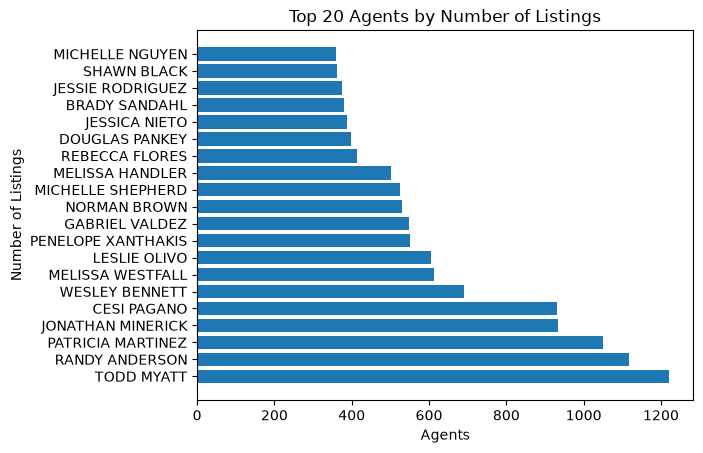

In [11]:
plt.barh(y=agents.index[:20], width=agents.values[:20])
plt.ylabel("Number of Listings")
plt.xlabel("Agents")
plt.title("Top 20 Agents by Number of Listings")

Text(0.5, 1.0, 'Top 20 Offices by Number of Listings')

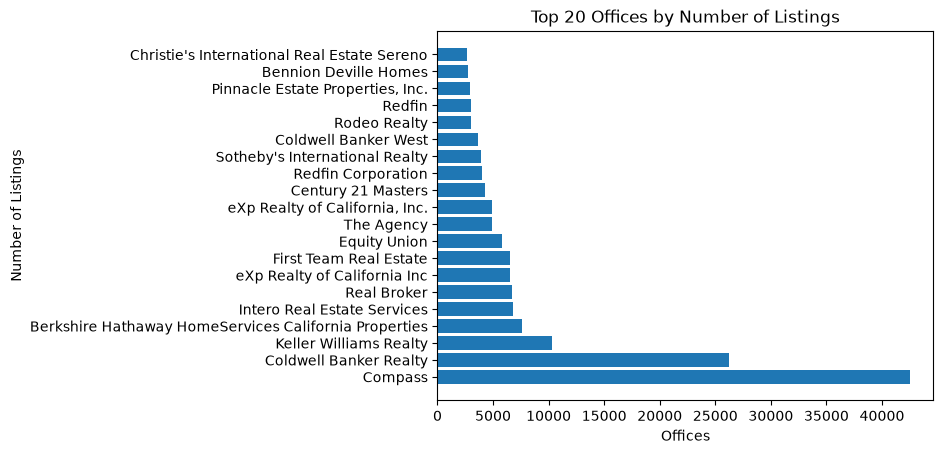

In [12]:
office = listing.groupby("ListOfficeName").size().sort_values(ascending=False)
plt.barh(y=office.index[:20], width=office.values[:20])
plt.ylabel("Number of Listings")
plt.xlabel("Offices")
plt.title("Top 20 Offices by Number of Listings")

### Potential columns to remove:
'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName'

In [13]:
listing.drop(columns=["ListAgentEmail", "ListAgentFirstName", "ListAgentLastName"], inplace=True)

In [14]:
listing.columns

Index(['OriginalListPrice', 'ListingKey', 'Latitude', 'Longitude',
       'UnparsedAddress', 'PropertyType', 'LivingArea', 'ListPrice',
       'DaysOnMarket', 'ListOfficeName', 'ListAgentFullName',
       'ListingKeyNumeric', 'MLSAreaMajor', 'CountyOrParish', 'MlsStatus',
       'AttachedGarageYN', 'ParkingTotal', 'PropertySubType', 'LotSizeAcres',
       'YearBuilt', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BedroomsTotal',
       'ContractStatusChangeDate', 'ListingContractDate', 'StateOrProvince',
       'FireplaceYN', 'Stories', 'Levels', 'LotSizeArea', 'MainLevelBedrooms',
       'NewConstructionYN', 'GarageSpaces', 'HighSchoolDistrict', 'PostalCode',
       'AssociationFee', 'LotSizeSquareFeet', 'year_month', 'Month', 'Year'],
      dtype='str')

### Coordinate check

Text(0.5, 1.0, 'Boxplot of Latitude Values in Listings')

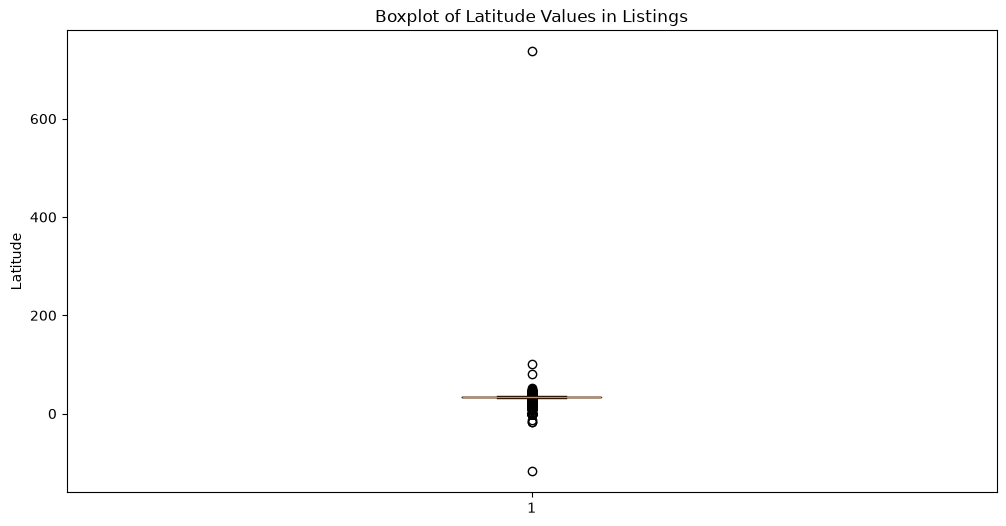

In [15]:
lat = listing.get("Latitude").dropna()
plt.figure(figsize=(12, 6))
plt.boxplot(lat)
plt.ylabel("Latitude")
plt.title("Boxplot of Latitude Values in Listings")

Text(0.5, 1.0, 'Boxplot of Longitude Values in Listings')

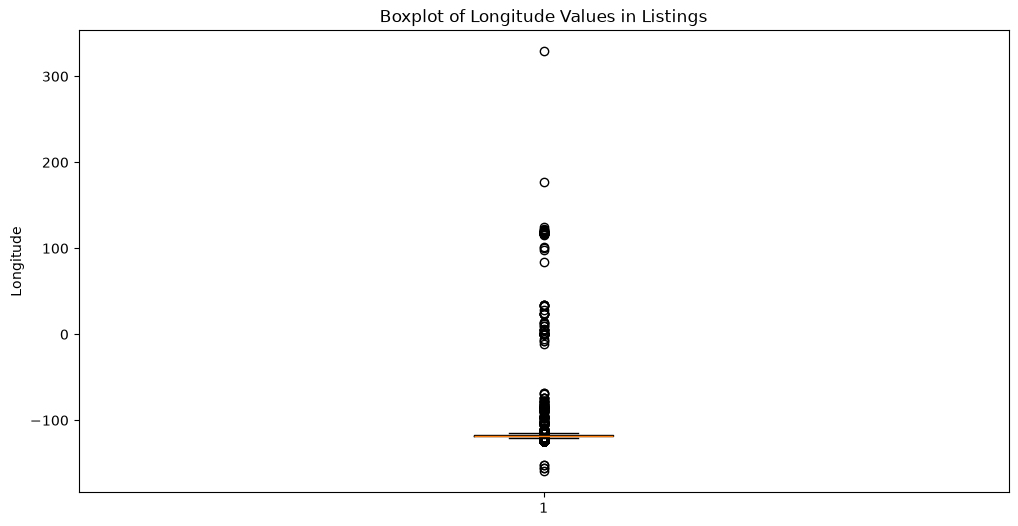

In [16]:
longitude = listing.get("Longitude").dropna()
plt.figure(figsize=(12, 6))
plt.boxplot(longitude)
plt.ylabel("Longitude")
plt.title("Boxplot of Longitude Values in Listings")

### California coordinate boundary check

In [17]:
city_path = Path("data/raw/city_boundaries/City_and_County_Boundaries.geojson")
city_gdf = gpd.read_file(city_path)
city_gdf = city_gdf.set_crs("EPSG:4326")

california_boundary = city_gdf.dissolve()
CALIFORNIA_LON_MIN, CALIFORNIA_LAT_MIN, CALIFORNIA_LON_MAX, CALIFORNIA_LAT_MAX = city_gdf.total_bounds

def validate_coordinates(row):
    latitude = row["Latitude"]
    longitude = row["Longitude"]

    has_coordinate = pd.notna(latitude) and pd.notna(longitude)
    if not has_coordinate:
        return "missing_coordinate"

    valid_coordinate = (-90 <= latitude <= 90) and (-180 <= longitude <= 180)
    if not valid_coordinate:
        return "invalid_coordinate"

    inside_california_bbox = (
        CALIFORNIA_LAT_MIN <= latitude <= CALIFORNIA_LAT_MAX
        and CALIFORNIA_LON_MIN <= longitude <= CALIFORNIA_LON_MAX
    )
    if inside_california_bbox:
        return "inside_california_bbox"

    return "outside_california_bbox"


listing["coordinate_status"] = listing[["Latitude", "Longitude"]].apply(
    validate_coordinates, axis=1
)
listing["coordinate_valid"] = listing["coordinate_status"].isin([
    "inside_california_bbox",
    "outside_california_bbox",
])
listing["inside_california_bbox"] = listing["coordinate_status"] == "inside_california_bbox"

california_bounds = pd.Series({
    "latitude_min": CALIFORNIA_LAT_MIN,
    "latitude_max": CALIFORNIA_LAT_MAX,
    "longitude_min": CALIFORNIA_LON_MIN,
    "longitude_max": CALIFORNIA_LON_MAX,
})
california_bounds

latitude_min      32.534288
latitude_max      42.009504
longitude_min   -124.421765
longitude_max   -114.130793
dtype: float64

In [18]:
status_counts = listing["coordinate_status"].value_counts(dropna=False)
coordinate_summary = pd.DataFrame({
    "count": status_counts,
    "percent": (status_counts / len(listing) * 100).round(2),
})

status_order = [
    "inside_california_bbox",
    "outside_california_bbox",
    "invalid_coordinate",
    "missing_coordinate",
]
coordinate_summary = coordinate_summary.reindex(status_order).fillna(0)
coordinate_summary

,count,percent
coordinate_status,,
inside_california_bbox,510909,86.30
outside_california_bbox,334,0.06
invalid_coordinate,4,0.00
missing_coordinate,80751,13.64


In [19]:
listing_filtered = listing[listing["coordinate_valid"]].copy()
listing_gdf = gpd.GeoDataFrame(
    listing_filtered,
    geometry=gpd.points_from_xy(listing_filtered["Longitude"], listing_filtered["Latitude"]),
    crs="EPSG:4326"
)

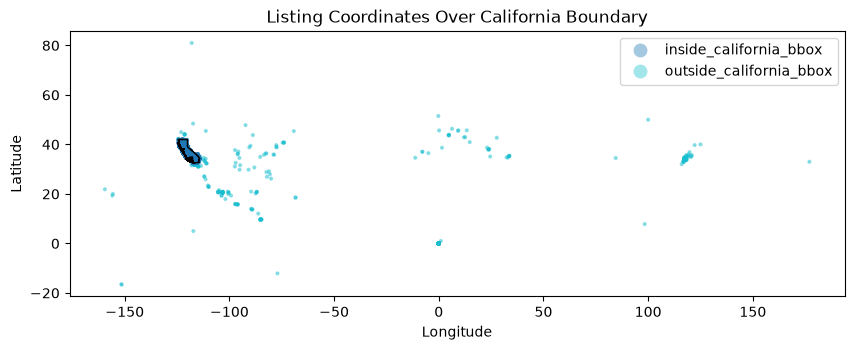

In [23]:
fig, ax = plt.subplots(figsize=(10, 12))

california_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1,
)

listing_gdf.plot(
    ax=ax,
    column="coordinate_status",
    markersize=4,
    alpha=0.4,
    legend=True,
)

ax.set_title("Listing Coordinates Over California Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

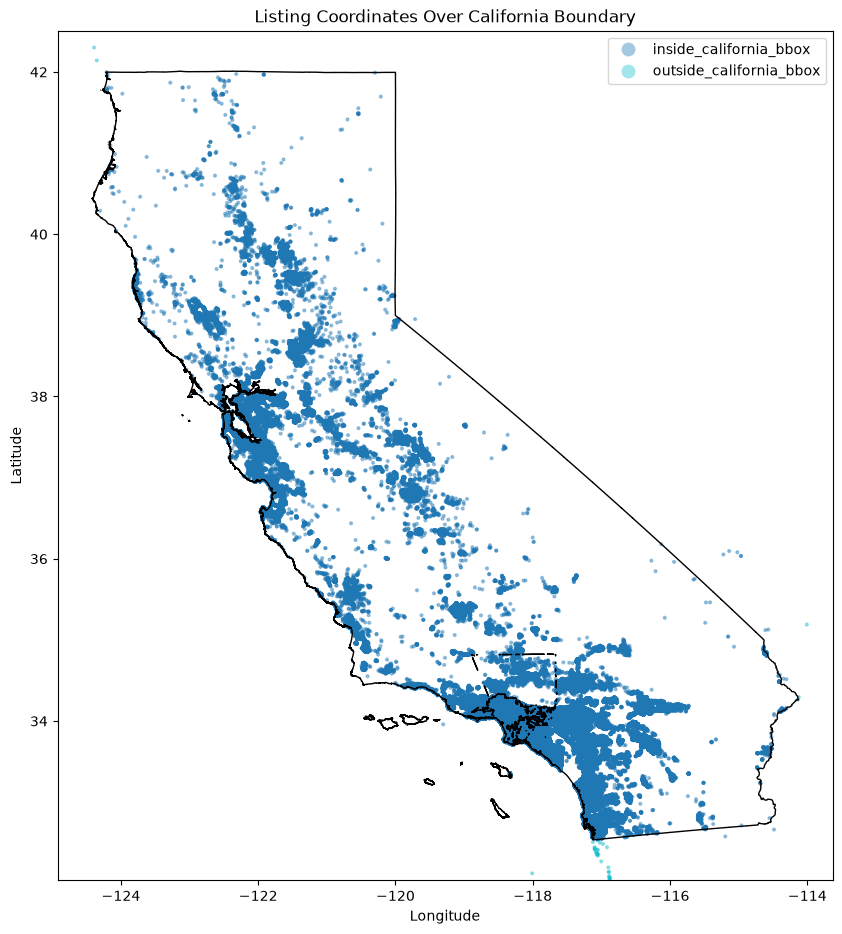

In [20]:
fig, ax = plt.subplots(figsize=(10, 12))

california_boundary.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1,
)

listing_gdf.plot(
    ax=ax,
    column="coordinate_status",
    markersize=4,
    alpha=0.4,
    legend=True,
)

longitude_padding = 0.5
latitude_padding = 0.5
ax.set_xlim(CALIFORNIA_LON_MIN - longitude_padding, CALIFORNIA_LON_MAX + longitude_padding)
ax.set_ylim(CALIFORNIA_LAT_MIN - latitude_padding, CALIFORNIA_LAT_MAX + latitude_padding)

ax.set_title("Listing Coordinates Over California Boundary")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

### Filtering invalid numerical values

In [21]:
listing.shape[0]

591998

In [22]:
columns = ["LivingArea", "DaysOnMarket", "BedroomsTotal", "BathroomsTotalInteger"]
for column in columns:
    listing = listing[listing[column] >= 0]

listing.shape[0]

591193

- Before count: 591998
- After count: 591193